In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Customer Churn Analysis & Prediction

# Problem Statement:
# Customer churn is a critical challenge for subscription-based businesses.
# In this project, I analyze customer behavior patterns and build a predictive
# model to identify customers likely to churn, enabling data-driven retention strategies.

In [3]:
df_customers = pd.read_csv('./data/WA_Fn-UseC_-Telco-Customer-Churn.csv')


In [4]:
df_customers['Churn'] = df_customers['Churn'].map({'Yes': 1, 'No': 0})


In [5]:
df_customers.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


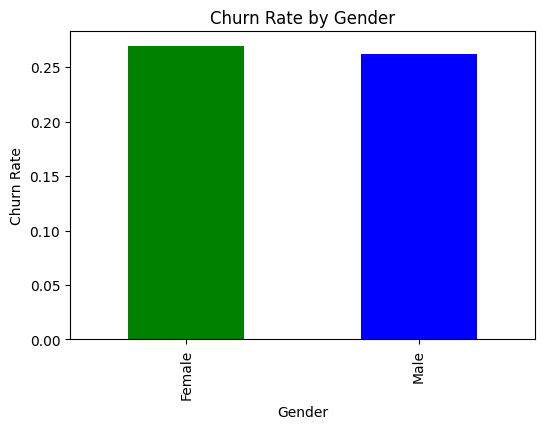

In [6]:
import matplotlib.pyplot as plt

df_plot = df_customers.groupby('gender')['Churn'].mean()

plt.figure(figsize=(6,4))
df_plot.plot(kind='bar', color=['green', 'blue'])
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.xlabel('Gender')
plt.show()


### Insight:
Female customers show a slightly higher churn rate compared to male customers,
suggesting the need for targeted engagement strategies.


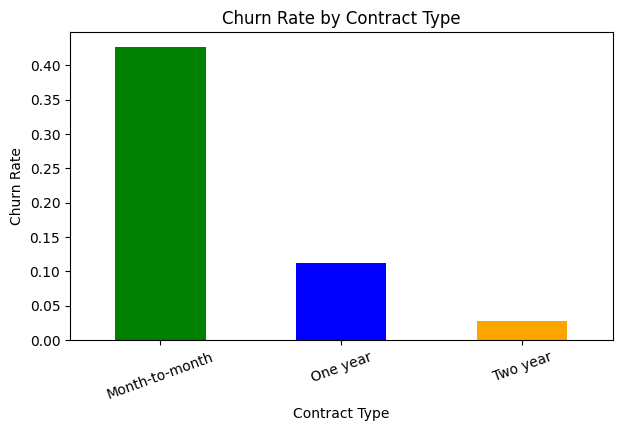

In [7]:
import matplotlib.pyplot as plt

df_plot = df_customers.groupby('Contract')['Churn'].mean()

plt.figure(figsize=(7,4))
df_plot.plot(kind='bar', color=['green', 'blue', 'orange'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.xticks(rotation=20)
plt.show()


### Insight:
#Month-to-month contracts have significantly higher churn, indicating that
#longer contract commitments help improve customer retention.


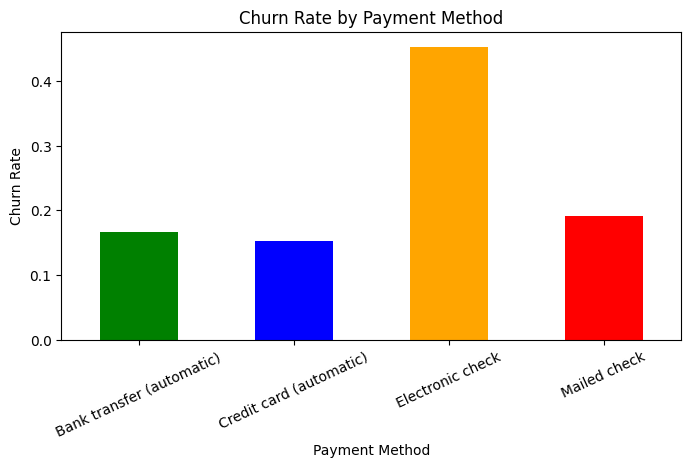

In [8]:
import matplotlib.pyplot as plt

df_plot = df_customers.groupby('PaymentMethod')['Churn'].mean()

plt.figure(figsize=(8,4))
df_plot.plot(kind='bar', color=['green', 'blue', 'orange', 'red'])
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate')
plt.xlabel('Payment Method')
plt.xticks(rotation=25)
plt.show()


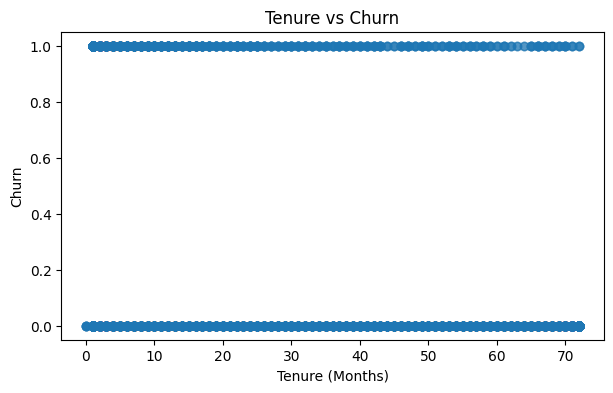

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7,4))
plt.scatter(df_customers['tenure'], df_customers['Churn'], alpha=0.3)
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn')
plt.show()


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [11]:
df_model = df_customers.copy()

for col in df_model.select_dtypes(include='object').columns:
    if col != 'customerID':
        df_model[col] = LabelEncoder().fit_transform(df_model[col])


In [12]:
X = df_model.drop(['Churn', 'customerID'], axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


c:\Users\Aadya Kapoor\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8168914123491838

Confusion Matrix:
 [[939  97]
 [161 212]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [15]:
## Conclusion

# This project demonstrates how exploratory data analysis combined with
# logistic regression can be used to predict customer churn.

# Key findings:
# - Contract type and tenure are strong indicators of churn
# - Month-to-month customers are at higher risk
# - Logistic Regression provides an interpretable baseline model

# Future improvements could include:
# - Trying tree-based models (Random Forest / XGBoost)
# - Feature scaling and hyperparameter tuning
# - Deploying the model as a simple web application
